In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from sklearn.metrics import r2_score

import os
import sys

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')

from funcs import *
from clean_and_combine import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# Finding waves to run

I want to look into Maxime's results and find 3 waves at 40 cm water depth that show damping. I want to find the amplitude from the first probe (undisturbed wave) and use this to scale to water depth of 30 and 20 cm to assess the same wave at different depths. 

This notebook looks at maximes results for:
* Water depth 30 cm
* Frequency: 0.59 Hz
* Amplitude: 0.3 Volt
* With and without the plates

I do not want to look at all 20 probes in the virtual array, but use 4. 

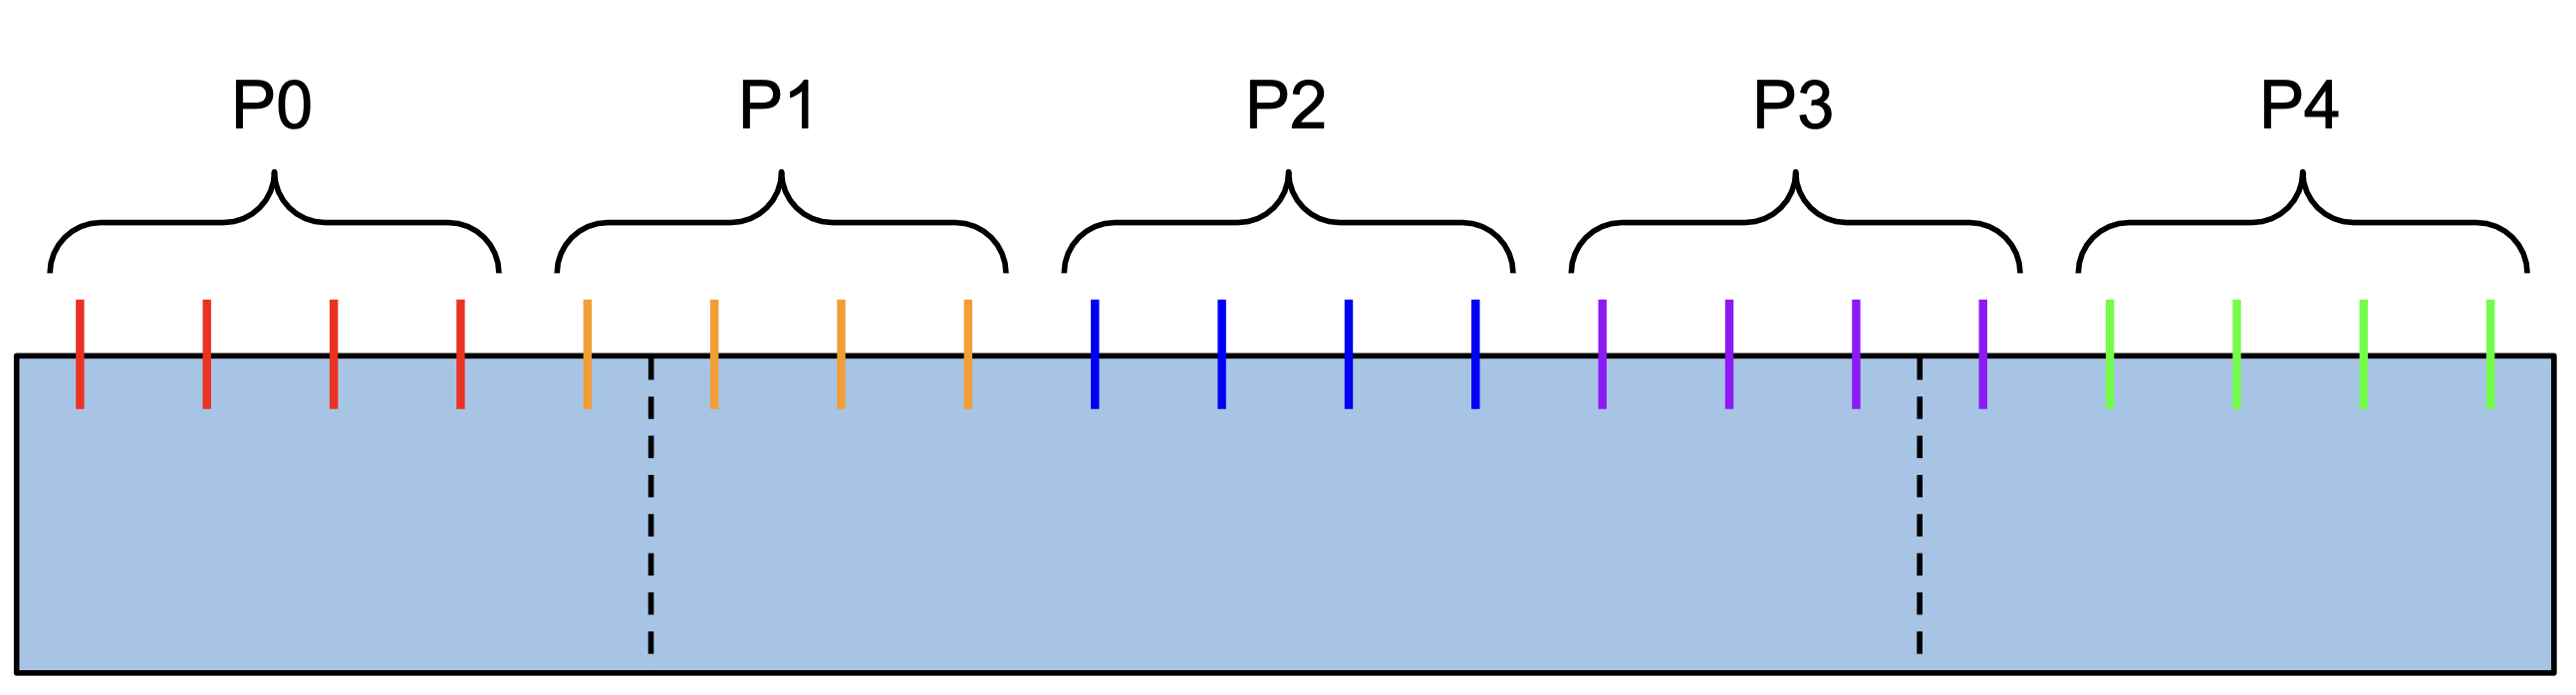

In [36]:
image_path = '/Users/kjesta/Desktop/Master prosjekt/Figurer/probe_positions.png'
display(Image(filename=image_path))

So for the given experiment, I will look at data from:
1) Probe 1 at position 0 (P0)
2) Probe 2 at position 1 (P1)
3) Probe 2 at position 2 (P2)
4) Probe 3 at position 3 (P3)

First, I open the files, process them and pick out the four probes I want.

In [2]:
headers = ['time', 'probe_1', 'probe_2', 'probe_3', 'probe_4', 'sound_speed']

path_run1_P0 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P0/f059/f059_A03_P0_run1.csv'
path_run2_P0 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P0/f059/f059_A03_P0_run2.csv'
path_run3_P0 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P0/f059/f059_A03_P0_run3.csv'

run1_P0 = pd.read_csv(path_run1_P0)
run2_P0 = pd.read_csv(path_run2_P0)
run3_P0 = pd.read_csv(path_run3_P0)

run1_P0.columns = headers
run2_P0.columns = headers
run3_P0.columns = headers

run1_P0_clean = clean(run1_P0)
run2_P0_clean = clean(run2_P0)
run3_P0_clean = clean(run3_P0)

run1_P0_clean_filtered = low_pass(run1_P0_clean)
run2_P0_clean_filtered = low_pass(run2_P0_clean)
run3_P0_clean_filtered = low_pass(run3_P0_clean)

P0_combined_plates = combine_runs(run1_P0_clean_filtered, run2_P0_clean_filtered, run3_P0_clean_filtered)
P0_combined_plates.head()

,time,probe_1,probe_2,probe_3,probe_4,sound_speed
0,0.000,-0.000009,0.000008,0.000050,-0.000005,343.263333
1,0.004,-0.000009,-0.000019,-0.000010,-0.000005,343.263333
2,0.008,-0.000009,-0.000015,-0.000002,-0.000005,343.263333
3,0.012,-0.000009,-0.000018,-0.000009,-0.000005,343.263333
4,0.016,-0.000009,-0.000019,-0.000010,-0.000005,343.263333


In [4]:
headers = ['time', 'probe_1', 'probe_2', 'probe_3', 'probe_4', 'sound_speed']

path_run1_P0 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P0/f059/f059_A030_P0_run1.csv'
path_run2_P0 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P0/f059/f059_A030_P0_run2.csv'
path_run3_P0 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P0/f059/f059_A030_P0_run3.csv'

run1_P0 = pd.read_csv(path_run1_P0)
run2_P0 = pd.read_csv(path_run2_P0)
run3_P0 = pd.read_csv(path_run3_P0)

run1_P0.columns = headers
run2_P0.columns = headers
run3_P0.columns = headers

run1_P0_clean = clean(run1_P0)
run2_P0_clean = clean(run2_P0)
run3_P0_clean = clean(run3_P0)

run1_P0_clean_filtered = low_pass(run1_P0_clean)
run2_P0_clean_filtered = low_pass(run2_P0_clean)
run3_P0_clean_filtered = low_pass(run3_P0_clean)

P0_combined_none = combine_runs(run1_P0_clean_filtered, run2_P0_clean_filtered, run3_P0_clean_filtered)
P0_combined_none.head()

,time,probe_1,probe_2,probe_3,probe_4,sound_speed
0,0.000,0.000007,-0.000050,0.000004,0.000008,343.436667
1,0.004,0.000007,-0.000020,-0.000026,0.000008,343.436667
2,0.008,0.000007,-0.000008,-0.000022,0.000008,343.436667
3,0.012,0.000007,0.000003,-0.000024,0.000008,343.436667
4,0.016,0.000007,0.000008,-0.000021,0.000008,343.436667


In [5]:
path_run1_P1 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P1/f059/f059_A03_P1_run1.csv'
path_run2_P1 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P1/f059/f059_A03_P1_run2.csv'
path_run3_P1 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P1/f059/f059_A03_P1_run3.csv'

run1_P1 = pd.read_csv(path_run1_P1)
run2_P1 = pd.read_csv(path_run2_P1)
run3_P1 = pd.read_csv(path_run3_P1)

run1_P1.columns = headers
run2_P1.columns = headers
run3_P1.columns = headers

run1_P1_clean = clean(run1_P1)
run2_P1_clean = clean(run2_P1)
run3_P1_clean = clean(run3_P1)

run1_P1_clean_filtered = low_pass(run1_P1_clean)
run2_P1_clean_filtered = low_pass(run2_P1_clean)
run3_P1_clean_filtered = low_pass(run3_P1_clean)

P1_combined_plates = combine_runs(run1_P1_clean_filtered, run2_P1_clean_filtered, run3_P1_clean_filtered)
P1_combined_plates.head()

,time,probe_1,probe_2,probe_3,probe_4,sound_speed
0,0.000,0.000018,0.000002,-0.00001,-0.000040,343.333333
1,0.004,-0.000009,0.000002,-0.00001,-0.000040,343.333333
2,0.008,-0.000005,0.000002,-0.00001,-0.000040,343.333333
3,0.012,-0.000008,0.000002,-0.00001,-0.000038,343.333333
4,0.016,-0.000009,0.000002,-0.00001,-0.000032,343.333333


In [6]:
path_run1_P1 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P1/f059/f059_A030_P1_run1.csv'
path_run2_P1 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P1/f059/f059_A030_P1_run2.csv'
path_run3_P1 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P1/f059/f059_A030_P1_run3.csv'

run1_P1 = pd.read_csv(path_run1_P1)
run2_P1 = pd.read_csv(path_run2_P1)
run3_P1 = pd.read_csv(path_run3_P1)

run1_P1.columns = headers
run2_P1.columns = headers
run3_P1.columns = headers

run1_P1_clean = clean(run1_P1)
run2_P1_clean = clean(run2_P1)
run3_P1_clean = clean(run3_P1)

run1_P1_clean_filtered = low_pass(run1_P1_clean)
run2_P1_clean_filtered = low_pass(run2_P1_clean)
run3_P1_clean_filtered = low_pass(run3_P1_clean)

P1_combined_none = combine_runs(run1_P1_clean_filtered, run2_P1_clean_filtered, run3_P1_clean_filtered)
P1_combined_none.head()

,time,probe_1,probe_2,probe_3,probe_4,sound_speed
0,0.000,0.00001,0.000107,2.950000e-05,-0.000044,343.363333
1,0.004,0.00001,0.000107,-5.000000e-07,-0.000014,343.363333
2,0.008,0.00001,0.000107,3.700000e-06,-0.000002,343.363333
3,0.012,0.00001,0.000107,1.000000e-07,0.000009,343.363333
4,0.016,0.00001,0.000106,-2.000000e-07,0.000014,343.363333


In [7]:
headers = ['time', 'probe_1', 'probe_2', 'probe_3', 'probe_4', 'sound_speed']

path_run1_P2 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P2/f059/f059_A03_P2_run1.csv'
path_run2_P2 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P2/f059/f059_A03_P2_run2.csv'
path_run3_P2 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P2/f059/f059_A03_P2_run3.csv'

run1_P2 = pd.read_csv(path_run1_P2)
run2_P2 = pd.read_csv(path_run2_P2)
run3_P2 = pd.read_csv(path_run3_P2)

run1_P2.columns = headers
run2_P2.columns = headers
run3_P2.columns = headers

run1_P2_clean = clean(run1_P2)
run2_P2_clean = clean(run2_P2)
run3_P2_clean = clean(run3_P2)

run1_P2_clean_filtered = low_pass(run1_P2_clean)
run2_P2_clean_filtered = low_pass(run2_P2_clean)
run3_P2_clean_filtered = low_pass(run3_P2_clean)

P2_combined_plates = combine_runs(run1_P2_clean_filtered, run2_P2_clean_filtered, run3_P2_clean_filtered)
P2_combined_plates.head()

,time,probe_1,probe_2,probe_3,probe_4,sound_speed
0,0.000,-0.00003,0.000002,0.000006,0.000080,343.503333
1,0.004,-0.00003,0.000002,0.000006,0.000080,343.503333
2,0.008,-0.00003,0.000002,0.000006,0.000063,343.503333
3,0.012,-0.00003,0.000002,0.000006,0.000054,343.503333
4,0.016,-0.00003,0.000001,0.000006,0.000043,343.503333


In [8]:
headers = ['time', 'probe_1', 'probe_2', 'probe_3', 'probe_4', 'sound_speed']

path_run1_P2 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P2/f059/f059_A030_P2_run1.csv'
path_run2_P2 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P2/f059/f059_A030_P2_run2.csv'
path_run3_P2 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P2/f059/f059_A030_P2_run3.csv'

run1_P2 = pd.read_csv(path_run1_P2)
run2_P2 = pd.read_csv(path_run2_P2)
run3_P2 = pd.read_csv(path_run3_P2)

run1_P2.columns = headers
run2_P2.columns = headers
run3_P2.columns = headers

run1_P2_clean = clean(run1_P2)
run2_P2_clean = clean(run2_P2)
run3_P2_clean = clean(run3_P2)

run1_P2_clean_filtered = low_pass(run1_P2_clean)
run2_P2_clean_filtered = low_pass(run2_P2_clean)
run3_P2_clean_filtered = low_pass(run3_P2_clean)

P2_combined_none = combine_runs(run1_P2_clean_filtered, run2_P2_clean_filtered, run3_P2_clean_filtered)
P2_combined_none.head()

,time,probe_1,probe_2,probe_3,probe_4,sound_speed
0,0.000,-0.000021,0.000013,0.000040,0.000008,343.36
1,0.004,-0.000021,0.000013,0.000040,-0.000022,343.36
2,0.008,-0.000004,0.000013,0.000040,-0.000017,343.36
3,0.012,0.000003,0.000013,0.000039,-0.000019,343.36
4,0.016,0.000008,0.000013,0.000035,-0.000016,343.36


In [9]:
headers = ['time', 'probe_1', 'probe_2', 'probe_3', 'probe_4', 'sound_speed']

path_run1_P3 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P3/f059/f059_A03_P3_run1.csv'
path_run2_P3 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P3/f059/f059_A03_P3_run2.csv'
path_run3_P3 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm/P3/f059/f059_A03_P3_run3.csv'

run1_P3 = pd.read_csv(path_run1_P3)
run2_P3 = pd.read_csv(path_run2_P3)
run3_P3 = pd.read_csv(path_run3_P3)

run1_P3.columns = headers
run2_P3.columns = headers
run3_P3.columns = headers

run1_P3_clean = clean(run1_P3)
run2_P3_clean = clean(run2_P3)
run3_P3_clean = clean(run3_P3)

run1_P3_clean_filtered = low_pass(run1_P3_clean)
run2_P3_clean_filtered = low_pass(run2_P3_clean)
run3_P3_clean_filtered = low_pass(run3_P3_clean)

P3_combined_plates = combine_runs(run1_P3_clean_filtered, run2_P3_clean_filtered, run3_P3_clean_filtered)
P3_combined_plates.head()

,time,probe_1,probe_2,probe_3,probe_4,sound_speed
0,0.000,-0.00003,0.000005,9.166667e-06,0.000020,343.15
1,0.004,-0.00003,0.000005,9.166667e-06,-0.000007,343.15
2,0.008,-0.00003,0.000005,-1.666667e-07,-0.000003,343.15
3,0.012,-0.00003,0.000005,-7.366667e-06,-0.000006,343.15
4,0.016,-0.00003,0.000005,-1.296667e-05,-0.000007,343.15


In [10]:
headers = ['time', 'probe_1', 'probe_2', 'probe_3', 'probe_4', 'sound_speed']

path_run1_P3 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P3/f059/f059_A030_P3_run1.csv'
path_run2_P3 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P3/f059/f059_A030_P3_run2.csv'
path_run3_P3 = '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/30 cm no plates/P3/f059/f059_A030_P3_run3.csv'

run1_P3 = pd.read_csv(path_run1_P3)
run2_P3 = pd.read_csv(path_run2_P3)
run3_P3 = pd.read_csv(path_run3_P3)

run1_P3.columns = headers
run2_P3.columns = headers
run3_P3.columns = headers

run1_P3_clean = clean(run1_P3)
run2_P3_clean = clean(run2_P3)
run3_P3_clean = clean(run3_P3)

run1_P3_clean_filtered = low_pass(run1_P3_clean)
run2_P3_clean_filtered = low_pass(run2_P3_clean)
run3_P3_clean_filtered = low_pass(run3_P3_clean)

P3_combined_none = combine_runs(run1_P3_clean_filtered, run2_P3_clean_filtered, run3_P3_clean_filtered)
P3_combined_none.head()

,time,probe_1,probe_2,probe_3,probe_4,sound_speed
0,0.000,0.000002,-0.000005,0.000005,-0.000021,343.29
1,0.004,0.000002,-0.000005,0.000005,-0.000021,343.29
2,0.008,-0.000003,-0.000005,0.000005,-0.000021,343.29
3,0.012,-0.000008,-0.000005,0.000005,-0.000021,343.29
4,0.016,-0.000015,-0.000005,0.000005,-0.000021,343.29


In [11]:
# Fill in for plotting:
f = 0.59  # Hz
A = 0.3  # V
H = 0.3  # m

In [12]:
# Dataframes for runs with plates
ref = P0_combined_plates[['time', 'probe_1']].copy()
start = P1_combined_plates[['time', 'probe_2']].copy()
mid = P2_combined_plates[['time', 'probe_2']].copy()
end = P3_combined_plates[['time', 'probe_3']].copy()

In [13]:
# Dataframes for runs without plates
ref_no = P0_combined_none[['time', 'probe_1']].copy()
start_no = P1_combined_none[['time', 'probe_2']].copy()
mid_no = P2_combined_none[['time', 'probe_2']].copy()
end_no = P3_combined_none[['time', 'probe_3']].copy()

In [14]:
# Positions of probes
X_base = np.array([11.075, 11.38, 11.685, 11.99])  # Base positions [m]
offset = 1.215  # distance each probe is moved between positions

# Number of position sets
num_positions = 5

# Create the array of all positions
x_probe_pos = np.array([X_base + offset * i for i in range(num_positions)]).flatten()

# The positions of the four probes we are using
ref_position = x_probe_pos[0]
start_position = x_probe_pos[5]
mid_position = x_probe_pos[9]
end_position = x_probe_pos[14]

The first probe shows the undisturbed incoming wave.

Text(0.5, 1.0, 'Reference Signal from probe at x = 11.075 m \n (0.3 m water depth, f = 0.59 Hz, A = 0.3 V)')

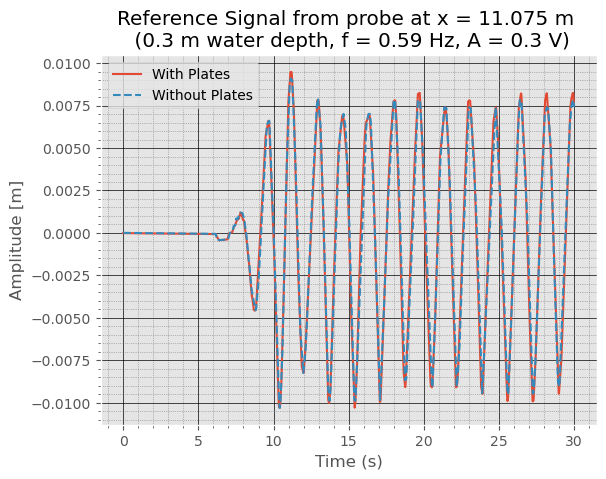

In [15]:
plt.plot(ref['time'], ref['probe_1'], label='With Plates')
plt.plot(ref_no['time'], ref_no['probe_1'], linestyle = '--', label='Without Plates')

plt.minorticks_on()
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude [m]')
plt.title(f'Reference Signal from probe at x = 11.075 m \n ({H} m water depth, f = {f} Hz, A = {A} V)')

The wave maker takes some time to build up a steady wave train. We therefore need to cut out the first parts of the signal.

In [16]:
# Cut out transient fronts
wave_maker_build_up_time = 15  # seconds

In [17]:
ref_cut = ref[ref['time'] >= wave_maker_build_up_time]
ref_no_cut = ref_no[ref_no['time'] >= wave_maker_build_up_time]

start_cut = start[start['time'] >= wave_maker_build_up_time]
start_no_cut = start_no[start_no['time'] >= wave_maker_build_up_time]

mid_cut = mid[mid['time'] >= wave_maker_build_up_time]
mid_no_cut = mid_no[mid_no['time'] >= wave_maker_build_up_time]

end_cut = end[end['time'] >= wave_maker_build_up_time]
end_no_cut = end_no[end_no['time'] >= wave_maker_build_up_time]

We want the mean of the signal to be still water and zero elevation. Therefore, I subtract the mean.

In [18]:
np.mean(ref_cut['probe_1'])

np.float64(-0.00020884391068407514)

In [19]:
np.mean(ref_no_cut['probe_1'])

np.float64(-0.00019991044112407995)

In [20]:
ref_cut['probe_1'] = ref_cut['probe_1'] - np.mean(ref_cut['probe_1'])
ref_no_cut['probe_1'] = ref_no_cut['probe_1'] - np.mean(ref_no_cut['probe_1'])

start_cut['probe_2'] = start_cut['probe_2'] - np.mean(start_cut['probe_2'])
start_no_cut['probe_2'] = start_no_cut['probe_2'] - np.mean(start_no_cut['probe_2'])

mid_cut['probe_2'] = mid_cut['probe_2'] - np.mean(mid_cut['probe_2'])
mid_no_cut['probe_2'] = mid_no_cut['probe_2'] - np.mean(mid_no_cut['probe_2'])

end_cut['probe_3'] = end_cut['probe_3'] - np.mean(end_cut['probe_3'])
end_no_cut['probe_3'] = end_no_cut['probe_3'] - np.mean(end_no_cut['probe_3'])

Checking that the subtraction worked:

In [21]:
np.mean(ref_cut['probe_1'])

np.float64(8.888895313251853e-20)

In [22]:
np.mean(ref_no_cut['probe_1'])

np.float64(-2.369739647012074e-19)

So I have cut out the first part of the timeseries where the wavetrain is not fully developed. However, the last part of the signal still contains distorted data as it may contain reflected waves from the far end of the tank.
At this moment in time I have not yet figured a way to combat this (or the case might be that there the whole signal is disturbed).

With the mean being zero,the standard deviation of the signal at the reference probe is proportional to the wave amplitude.

$$\eta(t) = Asin(\omega t)$$
$$\bar{\eta} = 0$$
$$\sigma = \sqrt{\frac{1}{T}\int_0^T \eta(t)^2 dt}$$
$$\sigma = \sqrt{\frac{1}{T}\int_0^T Asin^2(\omega t) dt}$$
$$\sigma = \sqrt{\frac{1}{T}\int_0^T A(\frac{1 + cos(2\omega t)}{2}) dt}$$
$$\sigma = A\sqrt{\frac{1}{2}(1 - \frac{1}{T}\int_0^T cos(2\omega t))} dt$$

and we know thatthe average of the cosine term over a full period is zero, so:

$$\frac{1}{T}\int_0^T cos(2\omega t) dt = 0$$
meaning,
$$\frac{1}{T}\int_0^T sin^2(\omega t) dt = \frac{1}{2}$$
$$\sigma = \frac{A}{\sqrt(2)}$$
$$A = \sqrt{2}\sigma$$

In [23]:
std_ref_plates = np.std(ref_cut['probe_1'])
std_ref_none = np.std(ref_no_cut['probe_1'])

print(f'Standard Deviation with Plates: {std_ref_plates:.6f} m')
print(f'Standard Deviation without Plates: {std_ref_none:.6f} m')

amplitude_ref_plates = std_ref_plates * np.sqrt(2)
amplitude_ref_none = std_ref_none * np.sqrt(2)

print(f'Wave Amplitude with Plates: {amplitude_ref_plates:.6f} m')
print(f'Wave Amplitude without Plates: {amplitude_ref_none:.6f} m')

Standard Deviation with Plates: 0.006025 m
Standard Deviation without Plates: 0.005883 m
Wave Amplitude with Plates: 0.008521 m
Wave Amplitude without Plates: 0.008319 m


Text(0.5, 0.98, 'Wave Probes Signals at Different Positions \n (0.3 m water depth, f = 0.59 Hz, A = 0.3 V)')

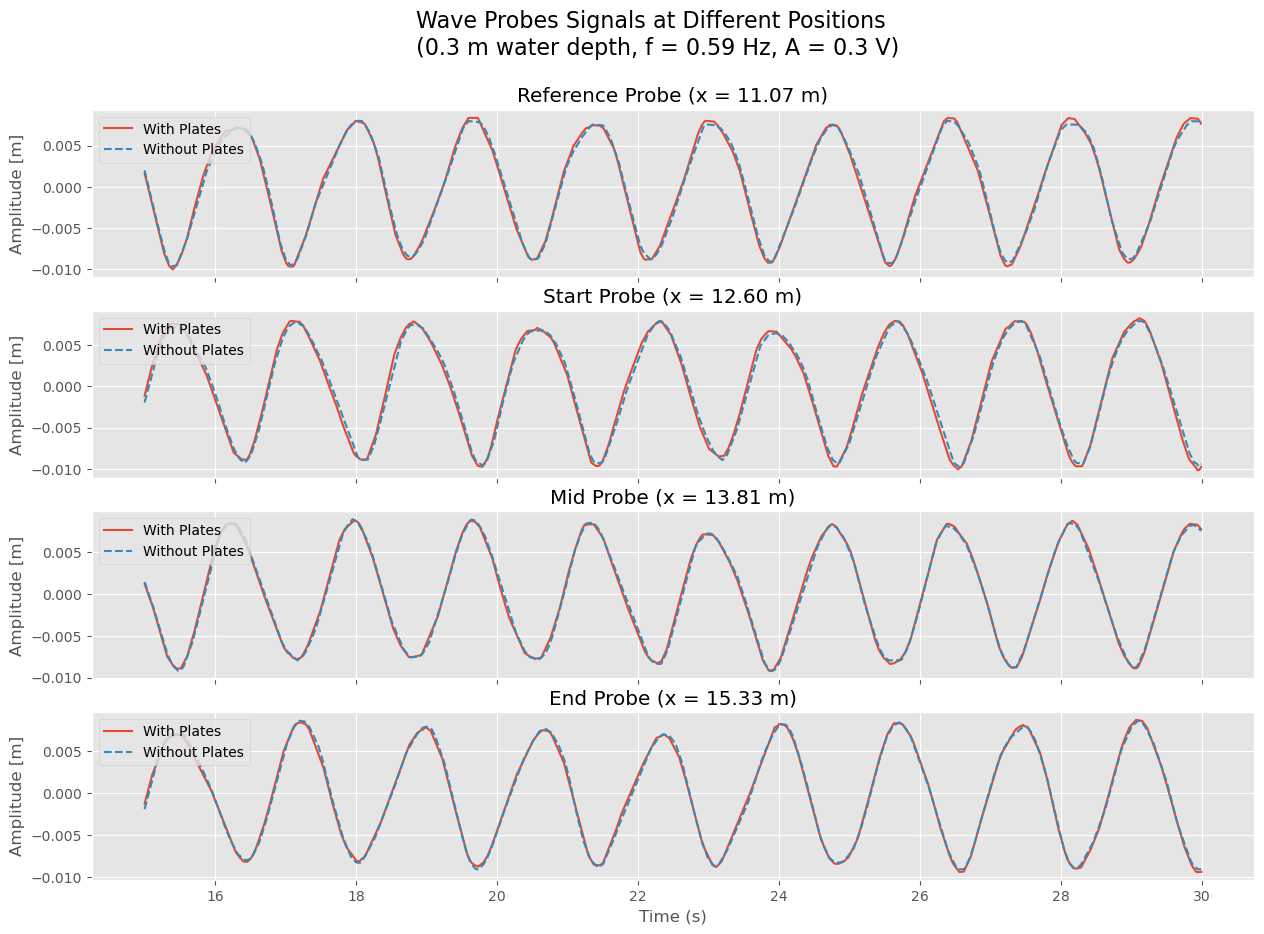

In [24]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax[0].plot(ref_cut['time'], ref_cut['probe_1'], label='With Plates')
ax[0].plot(ref_no_cut['time'], ref_no_cut['probe_1'], linestyle='--', label='Without Plates')
ax[0].set_title(f'Reference Probe (x = {ref_position:.2f} m)')
ax[0].set_ylabel('Amplitude [m]')

ax[1].plot(start_cut['time'], start_cut['probe_2'], label='With Plates')
ax[1].plot(start_no_cut['time'], start_no_cut['probe_2'], linestyle='--', label='Without Plates')
ax[1].set_title(f'Start Probe (x = {start_position:.2f} m)')
ax[1].set_ylabel('Amplitude [m]')

ax[2].plot(mid_cut['time'], mid_cut['probe_2'], label='With Plates')
ax[2].plot(mid_no_cut['time'], mid_no_cut['probe_2'], linestyle='--', label='Without Plates')
ax[2].set_title(f'Mid Probe (x = {mid_position:.2f} m)')
ax[2].set_ylabel('Amplitude [m]')

ax[3].plot(end_cut['time'], end_cut['probe_3'], label='With Plates')
ax[3].plot(end_no_cut['time'], end_no_cut['probe_3'], linestyle='--', label='Without Plates')
ax[3].set_title(f'End Probe (x = {end_position:.2f} m)')
ax[3].set_xlabel('Time (s)')
ax[3].set_ylabel('Amplitude [m]')

for axs in ax:
    axs.legend(loc='upper left')

fig.suptitle(f'Wave Probes Signals at Different Positions \n ({H} m water depth, f = {f} Hz, A = {A} V)', fontsize=16)

In [25]:
# Standard deviations after cutting out build-up time
std_start_plates = np.std(start_cut['probe_2'])
std_mid_plates = np.std(mid_cut['probe_2'])
std_end_plates = np.std(end_cut['probe_3'])

std_start_none = np.std(start_no_cut['probe_2'])
std_mid_none = np.std(mid_no_cut['probe_2'])
std_end_none = np.std(end_no_cut['probe_3'])

In [26]:
positions = [ref_position, start_position, mid_position, end_position]

beach_start = 12.4
beach_end = 15.45

In [27]:
std_with = [std_ref_plates, std_start_plates, std_mid_plates, std_end_plates]
std_no = [std_ref_none, std_start_none, std_mid_none, std_end_none]

coeff_with = np.polyfit(positions, std_with, 1)  
line_with = np.poly1d(coeff_with)            

coeff_no = np.polyfit(positions, std_no, 1) 
line_no = np.poly1d(coeff_no)

r2_with = r2_score(std_with, line_with(positions))
r2_no = r2_score(std_no, line_no(positions))

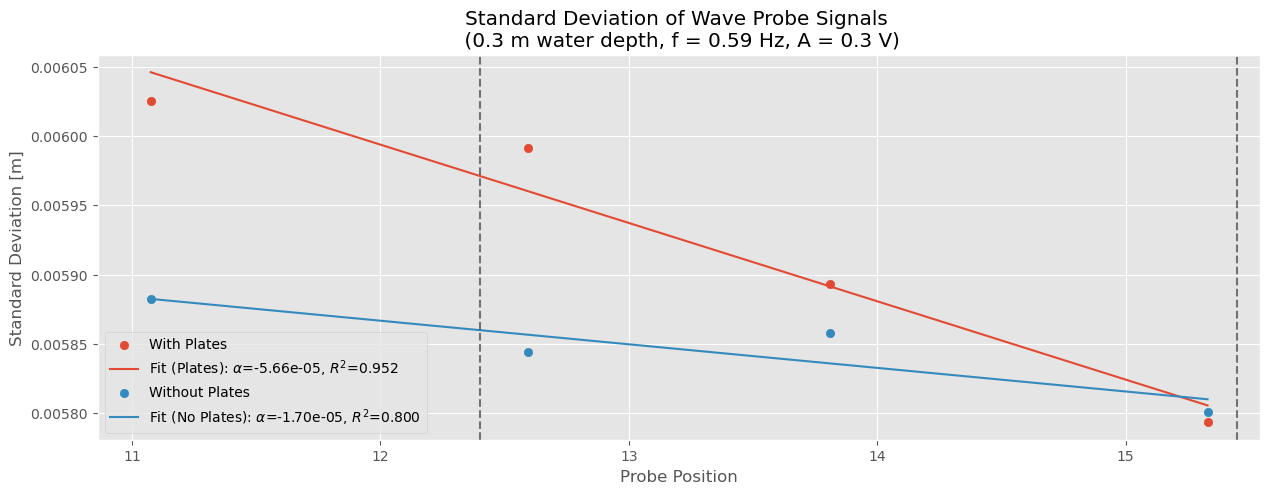

In [28]:
stds_plates = [std_ref_plates, std_start_plates, std_mid_plates, std_end_plates]
stds_none = [std_ref_none, std_start_none, std_mid_none, std_end_none]

fig, ax = plt.subplots(figsize=(15, 5))

ax.scatter(positions, stds_plates, marker='o', label='With Plates')
ax.plot(positions, line_with(positions), label=rf'Fit (Plates): $\alpha$={coeff_with[0]:.2e}, $R^2$={r2_with:.3f}')

ax.scatter(positions, stds_none, marker='o', label='Without Plates')
ax.plot(positions, line_no(positions), label=rf'Fit (No Plates): $\alpha$={coeff_no[0]:.2e}, $R^2$={r2_no:.3f}')

ax.axvline(beach_start, color= 'black', alpha=0.5, linestyle='--')
ax.axvline(beach_end, color='black', alpha=0.5, linestyle='--')

ax.set_xlabel('Probe Position')
ax.set_ylabel('Standard Deviation [m]')
plt.title(f'Standard Deviation of Wave Probe Signals \n ({H} m water depth, f = {f} Hz, A = {A} V)')
plt.legend()

In [29]:
amp_diff_plates = np.sqrt(2)*std_end_plates - amplitude_ref_plates
amp_diff_none = np.sqrt(2)*std_end_none - amplitude_ref_none

In [30]:
def est_wavelength(df, probe_positions):
    # Handling any nans that might have occured after combining the three runs
    df = df.interpolate(method='linear', limit_direction='both')

    signals = [[],[],[],[]]  # for storing probe signals

    for i in range(1, 5):
        signals[i-1] = df.iloc[:, i].values
    
    signals = np.array(signals)
    n_probes = 4
    
    dt = df['time'][1]

    # Calculate sampling frequency
    fs = 1 / dt  # Sampling frequency in Hz

    # Length of the time series
    n = len(df['time'])  # Number of samples

    # FFT (fast fourier transform) of each signal
    fft_signals = fft(signals, axis=1)
    freqs = fftfreq(n, d=dt)
    
    # Keep only positive frequencies
    pos_freqs = freqs[:n//2]
    fft_pos = fft_signals[:, :n//2]
    
    # Find the dominant frequency, here done at the first probe
    power = np.abs(fft_pos[0])**2
    dominant_idx = np.argmax(power[1:]) + 1 # skip the zero frequency
    f_dom = pos_freqs[dominant_idx]
    omega_dom = 2 * np.pi * f_dom

    # Extract phases at this frequency for each probe
    phases = np.angle(fft_pos[:, dominant_idx])
    unwrapped_phases = np.unwrap(phases)

    # Linear fit: phase = k * x + phi0 → slope = k
    coeffs = np.polyfit(probe_positions, unwrapped_phases, 1)
    
    k = coeffs[0]  # wave number (rad/m)

    # Wavelength
    wavelength = 2 * np.pi / np.abs(k)
    
    return wavelength, f_dom

In [31]:
undisturbed_wavelength_none, freq_none = est_wavelength(P0_combined_none, x_probe_pos[[0, 1, 2, 3]])
undisturbed_wavelength_plates, freq_plates = est_wavelength(P0_combined_plates, x_probe_pos[[0, 1, 2, 3]])

In [32]:
print(f'With plates: Wavelength = {undisturbed_wavelength_plates:.2f} m, Frequency = {freq_plates:.2f} Hz')
print(f'Without plates: Wavelength = {undisturbed_wavelength_none:.2f} m, Frequency = {freq_none:.2f} Hz')

With plates: Wavelength = 2.66 m, Frequency = 0.60 Hz
Without plates: Wavelength = 2.65 m, Frequency = 0.60 Hz


In [33]:
k_none = 2 * np.pi / undisturbed_wavelength_none
k_plates = 2 * np.pi / undisturbed_wavelength_plates

a_none = std_ref_none
a_with = std_ref_plates

ak_none = a_none * k_none
ak_with = a_with * k_plates

print(f'With Plates: ak = {ak_with:.6f}')
print(f'Without Plates: ak = {ak_none:.6f}')

With Plates: ak = 0.014244
Without Plates: ak = 0.013928


In [34]:
kh_none = k_none * H
kh_with = k_plates * H

print(f'With Plates: kH = {kh_with:.6f}')
print(f'Without Plates: kH = {kh_none:.6f}')

With Plates: kH = 0.709188
Without Plates: kH = 0.710286


# Summary of wave parameters

In [35]:
print('Summary of wave parameters for undisturbed incoming waves:')
print('----------------------------------------------------------')
print(f'Wave tank depth: {H} m, Frequency: {f} Hz, Amplitude setting: {A} V')
print()
print(f'With Plates: Wavelength = {undisturbed_wavelength_plates:.2f} m, Frequency = {freq_plates:.2f} Hz')
print(f'Without Plates: Wavelength = {undisturbed_wavelength_none:.2f} m, Frequency = {freq_none:.2f} Hz')
print()
print(f'With Plates: ak = {ak_with:.6f}, kH = {kh_with:.6f}')
print(f'Without Plates: ak = {ak_none:.6f}, kH = {kh_none:.6f}')
print()
print(f'Standard Deviation with Plates: {std_ref_plates:.6f} m')
print(f'Standard Deviation without Plates: {std_ref_none:.6f} m')
print()
print(f'Wave Amplitude with Plates: {amplitude_ref_plates:.6f} m')
print(f'Wave Amplitude without Plates: {amplitude_ref_none:.6f} m')
print()
print(f'Amplitude Difference at End Probe with Plates: {amp_diff_plates:.6f} m')
print(f'Amplitude Difference at End Probe without Plates: {amp_diff_none:.6f} m')
print(f'Damping caused by plates (walls subtracted): {(amp_diff_plates - amp_diff_none):.6f} m')
print(f'Percentage damping due to plates: {((amp_diff_plates -amp_diff_none) / (amp_diff_plates))*100:.6f} %')

Summary of wave parameters for undisturbed incoming waves:
----------------------------------------------------------
Wave tank depth: 0.3 m, Frequency: 0.59 Hz, Amplitude setting: 0.3 V

With Plates: Wavelength = 2.66 m, Frequency = 0.60 Hz
Without Plates: Wavelength = 2.65 m, Frequency = 0.60 Hz

With Plates: ak = 0.014244, kH = 0.709188
Without Plates: ak = 0.013928, kH = 0.710286

Standard Deviation with Plates: 0.006025 m
Standard Deviation without Plates: 0.005883 m

Wave Amplitude with Plates: 0.008521 m
Wave Amplitude without Plates: 0.008319 m

Amplitude Difference at End Probe with Plates: -0.000328 m
Amplitude Difference at End Probe without Plates: -0.000116 m
Damping caused by plates (walls subtracted): -0.000212 m
Percentage damping due to plates: 64.603124 %
